In [3]:
""" Carbon fluxes in Paul's observations """
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.constants import *
from utils.paths import *
from utils.plotting import *
from utils.analysis import *
from scipy.stats import linregress, t
from utils.analysis import get_spruce_carbonfluxes

prefix_list = ['UQ_20231113_2a', 'UQ_20231113_2b', 'UQ_20231113_2c']
#N_list = [2000,2000,2000]
N_list = [768,768,768]
BLOCK = 192
VAR_LIST = ["TOTVEGC_ABG_pima", "TOTVEGC_ABG_lala", "TOTVEGC_ABG_shrub",
            "ANPP_pima", "ANPP_lala", "ANPP_tree", "ANPP_shrub", 
            "NPP_moss", "BGNPP", "HR", "NEE", "TOTSOMC"]

In [9]:
def get_obs():
    """ Get the observational slope & value at ambient chamber """
    plot_list = [f'P{p:02g}' for p in chamber_list_complete]

    obs_varname = ["ABGbiomass evergreen conifer", "ABGbiomass deciduous conifer",
                   "ABGbiomass shrub", "ABGnpp evergreen conifer",
                   "ABGnpp deciduous conifer", # "ABGnpp shrub",
                   "ANPP Tree (~48%C)", "ANPP Shrub (~50%C)",
                   "NPP Sphag.", "BNPP Tree & Shrub", "RHCO2", "NCE"]

    obs_data = get_spruce_carbonfluxes().set_index(['Plot', 'Year'])

    t2m_obs = obs_data.loc[:, 'Mean Annual Temp. at 2 m']
    obs_data = obs_data.loc[:, obs_varname]
    obs_data.columns = VAR_LIST[:-1]

    collection = pd.DataFrame(np.nan,
                              index = pd.MultiIndex.from_product([VAR_LIST, ['amb', 'elev']]),
                              columns = ['mean', 'mean_std', 'slope', 'slope_std'])
    collection.index.names = ['Variable', 'CO2']

    for varname in VAR_LIST:
        for co2 in ['amb','elev']:
            if co2 == 'amb':
                filt = obs_data.index.get_level_values(0).isin([plot_list[0]] + plot_list[1::2])
            else:
                filt = obs_data.index.get_level_values(0).isin(plot_list[2::2])

            if varname != 'TOTSOMC':
                obs_temp = obs_data.loc[filt, varname]
                obs_T    = t2m_obs.loc[filt]

                filt2 = ~np.isnan(obs_T) & ~np.isnan(obs_temp)
                obs_temp = obs_temp.values[filt2]
                obs_T = obs_T.values[filt2]

                res = linregress(obs_T, obs_temp)

                ts = abs(t.ppf(0.05, len(obs_T) - 2))

                collection.loc[(varname, co2), 'slope'] = res.slope
                collection.loc[(varname, co2), 'slope_std'] = ts * res.stderr

                # use the average of all the chambers to be compatible with simulated results
                # obs_temp = obs_data.loc[obs_data.index.get_level_values(0) == plot_list[0], varname] # T0
                collection.loc[(varname, co2), 'mean'] = obs_temp.mean()
                collection.loc[(varname, co2), 'mean_std'] = obs_temp.std()
            else:
                collection.loc[(varname, co2), 'mean'] = 200000
                collection.loc[(varname, co2), 'mean_std'] = 500000

    return collection

In [12]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
collection_sim = {}

for N, prefix in zip(N_list, prefix_list):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :] = np.load(os.path.join(path_out, "extract", prefix, f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
    # convert unit from gC m-2 s-1 (per year) to gC m-2 (per year)
    collect[:, 3:, :, :] = collect[:, 3:, :, :] * 365 * 86400
    # revert the signs of NEE & HR to be compatible with Paul's data
    collect[:, -3:-2, :, :] = - collect[:, -3:-2, :, :]

    collection_sim[prefix] = collect

In [6]:
collection_sim[prefix].shape, collection_sim.keys()

((768, 12, 2, 4),
 dict_keys(['UQ_20231113_2a', 'UQ_20231113_2b', 'UQ_20231113_2c']))

In [7]:
# Get the parameters
def get_params(prefix, parname, N, ensemble_members = range(1, 2001)):
#    prefix = 'UQ_20240311'
#    parname = 'kmin_nuptake'
#    N = 2000
    uqroot = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', 'UQ', 
                            f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC')
    N = len(ensemble_members)
    count = 0
    for b in ensemble_members:
        hr = xr.open_dataset( os.path.join(uqroot, f'g{b:05d}', f'clm_params_{b:05d}.nc') )
        parvals = hr[parname].values
        hr.close()
        if count == 0:
            if parvals.shape == ():
                parcollect = np.full([N, 1], np.nan)
            else:
                parcollect = np.full([N, len(parvals)], np.nan)
        if parvals.shape == ():
            parcollect[count, 0] = parvals
        else:
            parcollect[count, :] = parvals.reshape(-1)
        count = count + 1
    return parcollect

In [10]:
collection_obs = get_obs()
collection_obs

mean       mean_std      slope  slope_std
Variable          CO2                                                     
TOTVEGC_ABG_pima  amb      959.913880     605.240088 -39.086412  65.954010
                  elev    1101.835040     526.907557 -92.404009  47.132177
TOTVEGC_ABG_lala  amb      312.209440     127.615716  -3.637558  14.155389
                  elev     221.804400     165.029905  10.075256  17.661378
TOTVEGC_ABG_shrub amb      270.340560     144.068094  14.201267  15.223928
                  elev     302.026760     127.044918  11.058754  13.301223
ANPP_pima         amb       90.367160      70.327725  -7.412613   7.372231
                  elev     108.182080      36.850668  -6.237117   3.351306
ANPP_lala         amb       41.946960      18.074609   0.357145   2.009258
                  elev      27.670120      19.440455   1.706969   2.033783
ANPP_tree         amb       89.396667      44.401978  -0.878865   3.756015
                  elev      89.340000      26.675232  -1.518294   2.862514
ANPP_shrub        amb      103.140667      34.649500   5.078297   2.444233
                  elev     133.439032      43.669913   8.051684   3.803961
NPP_moss          amb       93.539700      54.460756 -10.250541   3.237914
                  elev      64.657760      42.817475  -6.800788   3.995419
BGNPP             amb       75.163750      36.653675   6.770230   2.220529
                  elev      79.211250      42.878170  10.162000   2.957010
HR                amb     -429.644529      91.562006 -20.084135   4.317464
                  elev    -460.730872      84.337116 -22.430646   4.537966
NEE               amb     -174.324416     162.204511 -29.397569  10.000740
                  elev    -210.644919     127.722575 -26.863250  10.121259
TOTSOMC           amb   200000.000000  500000.000000        NaN        NaN
                  elev  200000.000000  500000.000000        NaN        NaN

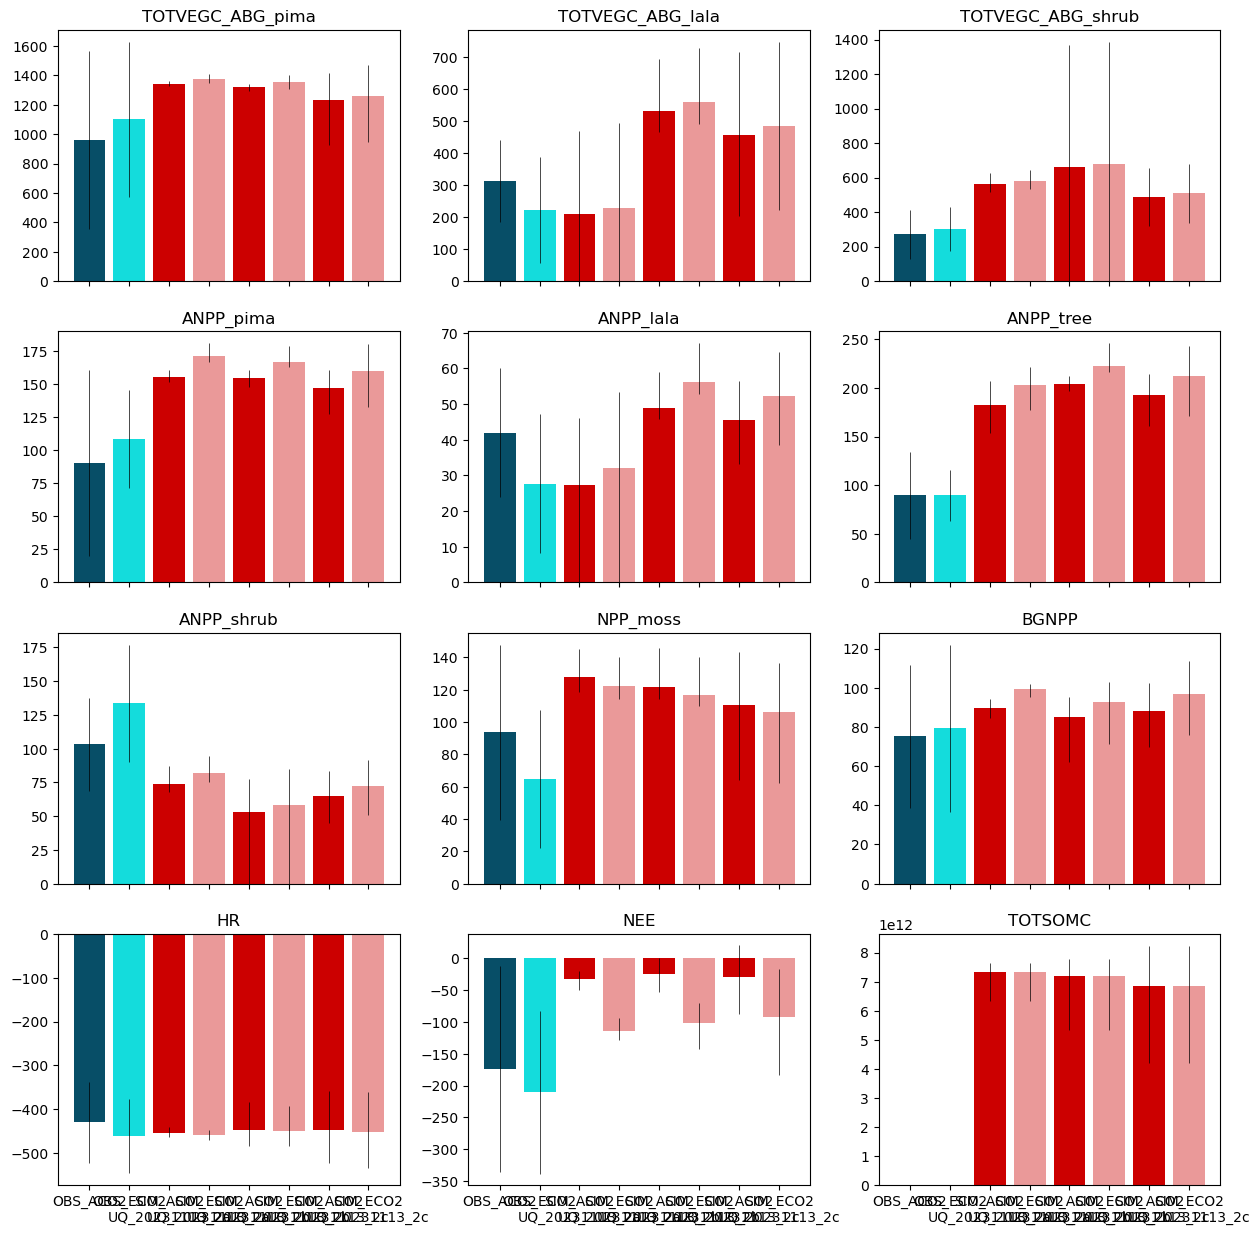

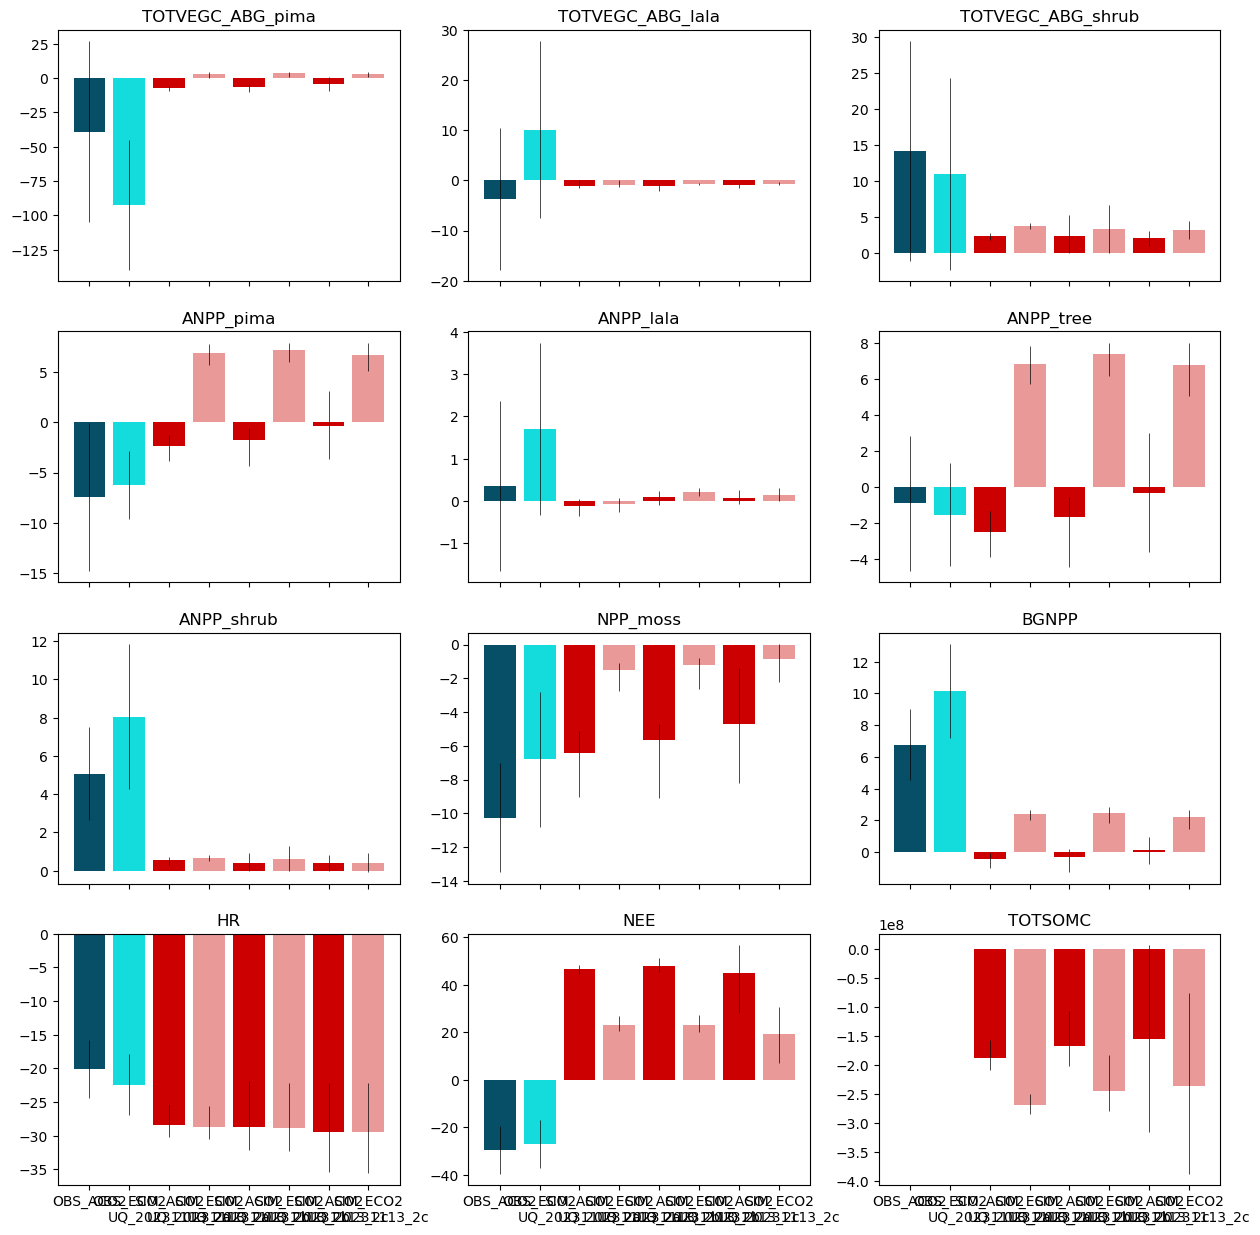

In [13]:
for quantity in ['mean', 'slope']:
    fig, axes = plt.subplots(4, 3, figsize = (15, 15), sharex = True, sharey = False)
    for i, ax in enumerate(axes.flat):
        if i >= len(VAR_LIST):
            ax.axis('off')
        else:
            varname = VAR_LIST[i]

            ax.bar([1, 2], collection_obs.loc[varname, quantity].values, 
                   color = ['#074e67', '#14dcdc'])
            ax.errorbar([1, 2], collection_obs.loc[varname, quantity].values, 
                        collection_obs.loc[varname, f'{quantity}_std'].values, 
                        ecolor = 'k', lw = 0, elinewidth = 0.5)
            ax.set_title(varname)

            if quantity == 'mean':
                k = 0
            else:
                k = 2

            for j, prefix in enumerate(prefix_list):
                temp = np.nanmean(collection_sim[prefix][:, i, :, k], axis = 0)
                temp_q5 = np.nanpercentile(collection_sim[prefix][:, i, :, k], 5, axis = 0)
                temp_q95 = np.nanpercentile(collection_sim[prefix][:, i, :, k], 95, axis = 0)

                ax.bar([3+j*2, 4+j*2], temp, color = ['#cc0000', '#ea9999'])
                ax.errorbar([3+j*2, 4+j*2], temp, [temp - temp_q5, temp_q95 - temp], 
                            ecolor = 'k', lw = 0, elinewidth = 0.5)

        if i >= 5:
            ax.set_xticks(range(1, 3 + 2 * len(prefix_list)))
            ax.set_xticklabels(['OBS_ACO2', 'OBS_ECO2'] + [f'{a}\n{prefix}' for prefix in prefix_list for a in  ['SIM_ACO2', 'SIM_ECO2']])

## Do more single run checks on parameter relationships

286


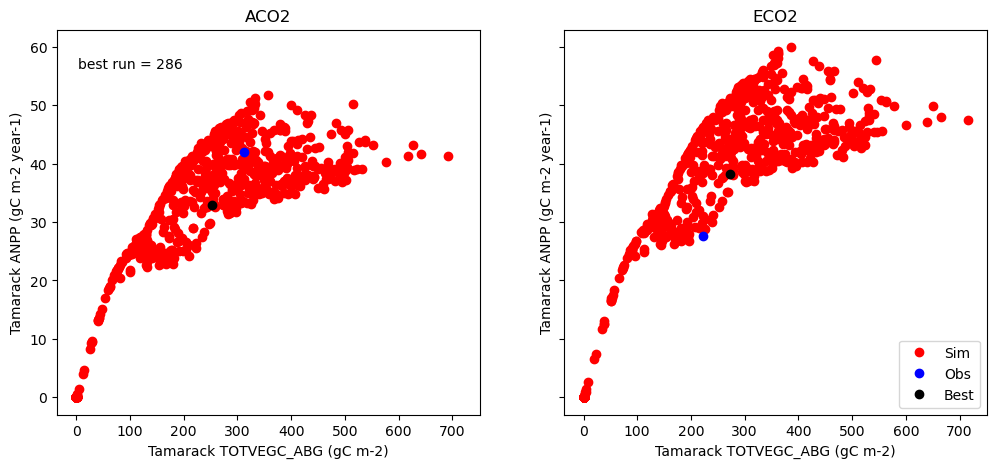

In [57]:
# Tamarack's AGNPP and TOTVEGC

prefix = 'UQ_20231113_2a'
N = 768

distance = {}
fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharex = True, sharey = True)
for i, co2 in enumerate(['amb', 'elev']):
    mean_anpp = collection_sim[prefix][:, 4, i, 0]
    mean_anpp_obs = collection_obs.loc[('ANPP_lala',co2), 'mean']
    mean_totvegc_abg = collection_sim[prefix][:, 1, i, 0]
    mean_totvegc_abg_obs = collection_obs.loc[('TOTVEGC_ABG_lala',co2), 'mean']

    ax = axes.flat[i]
    ax.plot(mean_totvegc_abg, mean_anpp, 'o', color = 'r', label = 'Sim')
    ax.plot(mean_totvegc_abg_obs,  mean_anpp_obs, 'o', color = 'b', label = 'Obs')

    distance[co2] = \
        np.sqrt( np.power((mean_totvegc_abg - mean_totvegc_abg_obs) / \
                          collection_obs.loc['TOTVEGC_ABG_lala', 'mean'].mean(), 2) \
                + np.power((mean_anpp - mean_anpp_obs) / \
                           collection_obs.loc['ANPP_lala', 'mean'].mean(), 2) )

distance2 = np.sqrt( distance['amb']**2 + distance['elev']**2 )
best = np.argmin(distance2)
print(best)

for i, co2 in enumerate(['amb', 'elev']):
    mean_anpp = collection_sim[prefix][best, 4, i, 0]
    mean_totvegc_abg = collection_sim[prefix][best, 1, i, 0]

    ax = axes.flat[i]
    ax.plot(mean_totvegc_abg,  mean_anpp, 'o', color = 'k', label = 'Best')
    ax.set_xlabel('Tamarack TOTVEGC_ABG (gC m-2)')
    ax.set_ylabel('Tamarack ANPP (gC m-2 year-1)')
    if i == 0:
        ax.set_title('ACO2')
    else:
        ax.set_title('ECO2')

    if i == 0:
        ax.text(0.05, 0.9, f'best run = {best}', transform = ax.transAxes)
    else:
        ax.legend(loc = 'lower right')

553


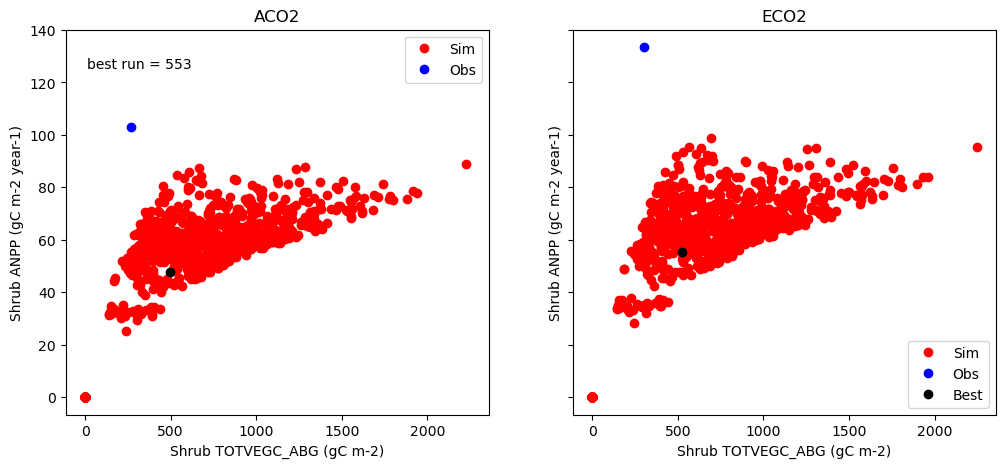

In [58]:
# Shrub's AGNPP and TOTVEGC

prefix = 'UQ_20231113_2b'
N = 768

distance = {}
fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharex = True, sharey = True)
for i, co2 in enumerate(['amb', 'elev']):
    mean_anpp = collection_sim[prefix][:, 6, i, 0]
    mean_anpp_obs = collection_obs.loc[('ANPP_shrub',co2), 'mean']
    mean_totvegc_abg = collection_sim[prefix][:, 2, i, 0]
    mean_totvegc_abg_obs = collection_obs.loc[('TOTVEGC_ABG_shrub',co2), 'mean']

    ax = axes.flat[i]
    ax.plot(mean_totvegc_abg, mean_anpp, 'o', color = 'r', label = 'Sim')
    ax.plot(mean_totvegc_abg_obs,  mean_anpp_obs, 'o', color = 'b', label = 'Obs')
    ax.legend()

    distance[co2] = \
        np.sqrt( np.power((mean_totvegc_abg - mean_totvegc_abg_obs) / \
                          collection_obs.loc['TOTVEGC_ABG_shrub', 'mean'].mean(), 2) \
                + np.power((mean_anpp - mean_anpp_obs) / \
                           collection_obs.loc['ANPP_shrub', 'mean'].mean(), 2) )

distance2 = np.sqrt( distance['amb']**2 + distance['elev']**2 )
best = np.argmin(distance2)
print(best)

for i, co2 in enumerate(['amb', 'elev']):
    mean_anpp = collection_sim[prefix][best, 4, i, 0]
    mean_totvegc_abg = collection_sim[prefix][best, 1, i, 0]

    ax = axes.flat[i]
    ax.plot(mean_totvegc_abg,  mean_anpp, 'o', color = 'k', label = 'Best')
    ax.set_xlabel('Shrub TOTVEGC_ABG (gC m-2)')
    ax.set_ylabel('Shrub ANPP (gC m-2 year-1)')
    if i == 0:
        ax.set_title('ACO2')
    else:
        ax.set_title('ECO2')

    if i == 0:
        ax.text(0.05, 0.9, f'best run = {best}', transform = ax.transAxes)
    else:
        ax.legend(loc = 'lower right')

In [12]:
prefix = 'UQ_20240317_5'
N = 2000

# Tree to shrub ratios
tree_shrub_ratio = collection_sim[prefix][:, 0, :, 0].mean(axis = 1) / collection_sim[prefix][:, 1, :, 0].mean(axis = 1)

# BGNPP/AGNPP
bg_ag_ratio = collection_sim[prefix][:, 2, :, 0].mean(axis = 1) / \
    collection_sim[prefix][:, 0:2, :, 0].sum(axis = 1).mean(axis = 1)

# The sensitivity of tree AGNPP to temperature
tree_sensitivity = collection_sim[prefix][:, 0, :, 2].mean(axis = 1)
shrub_sensitivity = collection_sim[prefix][:, 1, :, 2].mean(axis = 1)
bgnpp_sensitivity = collection_sim[prefix][:, 2, :, 2].mean(axis = 1)

# HR & NEE level
hr = collection_sim[prefix][:, 5, :, 0].mean(axis = 1)
hr_sensitivity = collection_sim[prefix][:, 5, :, 2].mean(axis = 1)
nee = collection_sim[prefix][:, 6, :, 0].mean(axis = 1)
nee_sensitivity = collection_sim[prefix][:, 6, :, 2].mean(axis = 1)

Text(0, 0.5, 'Sensitivity of NEE to warming')

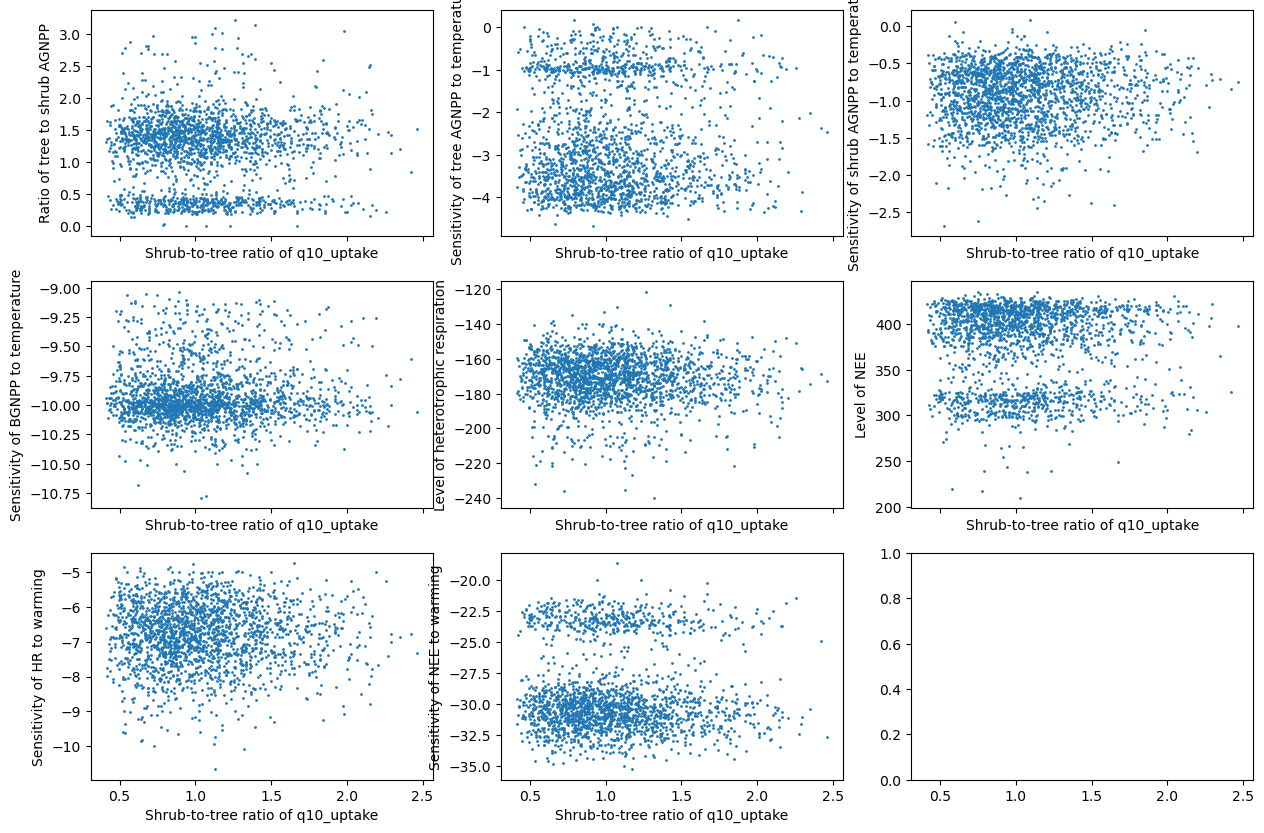

In [22]:
# without PFT-specific sizing, there is no result what so ever
q10_collect = get_params(prefix, 'q10_uptake', 2000)
q10_ratio = q10_collect[:,11] / q10_collect[:,2:3].mean(axis = 1)

fig, axes = plt.subplots(3, 3, figsize = (15, 10), sharex = True)

ax = axes.flat[0]
ax.plot(q10_ratio, tree_shrub_ratio, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Ratio of tree to shrub AGNPP')

ax = axes.flat[1]
ax.plot(q10_ratio, tree_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of tree AGNPP to temperature')

ax = axes.flat[2]
ax.plot(q10_ratio, shrub_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of shrub AGNPP to temperature')

ax = axes.flat[3]
ax.plot(q10_ratio, bgnpp_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of BGNPP to temperature')

ax = axes.flat[4]
ax.plot(q10_ratio, hr, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Level of heterotrophic respiration')

ax = axes.flat[5]
ax.plot(q10_ratio, nee, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Level of NEE')

ax = axes.flat[6]
ax.plot(q10_ratio, hr_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of HR to warming')

ax = axes.flat[7]
ax.plot(q10_ratio, nee_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of NEE to warming')

In [ ]:
# kmin_nuptake has the desired impact, but not large enough
# note smaller kmin_nuptake means greater uptake capability

kmincollect = get_params(prefix, 'kmin_nuptake', 2000)

xtemp = (kmincollect[:, 2] + kmincollect[:, 3]) / 2 / kmincollect[:, 11]

fig, axes = plt.subplots(2, 2, figsize = (10, 10))

ax = axes.flat[0]
ax.plot(xtemp, tree_shrub_ratio, 'o', ms = 1)
ax.set_xlabel('Ratio of kmin_nuptake of tree to shrub')
ax.set_ylabel('Ratio of tree to shrub AGNPP')

ax = axes.flat[1]
ax.plot(xtemp, tree_sensitivity, 'o', ms = 1)
ax.set_xlabel('Ratio of kmin_nuptake of tree to shrub')
ax.set_ylabel('Sensitivity of tree AGNPP to temperature')

ax = axes.flat[2]
ax.plot(xtemp, shrub_sensitivity, 'o', ms = 1)
ax.set_xlabel('Ratio of kmin_nuptake of tree to shrub')
ax.set_ylabel('Sensitivity of shrub AGNPP to temperature')

ax = axes.flat[3]
ax.plot(xtemp, bgnpp_sensitivity, 'o', ms = 1)
ax.set_xlabel('Ratio of kmin_nuptake of tree to shrub')
ax.set_ylabel('Sensitivity of BGNPP to temperature')

In [ ]:
# compet_pft_sminn
competn_collect = get_params(prefix, 'compet_pft_sminn', 2000)

# xtemp = (competn_collect[:, 2] + competn_collect[:, 3]) / 2 / competn_collect[:, 11]
xtemp = competn_collect[:, 11]

fig, axes = plt.subplots(2, 2, figsize = (10, 10))

ax = axes.flat[0]
ax.plot(xtemp, tree_shrub_ratio, 'o', ms = 1)
ax.set_xlabel('Ratio of competn_collect of tree to shrub')
ax.set_xscale('log')
ax.set_ylabel('Ratio of tree to shrub AGNPP')

ax = axes.flat[1]
ax.plot(xtemp, tree_sensitivity, 'o', ms = 1)
ax.set_xlabel('Ratio of competn_collect of tree to shrub')
ax.set_xscale('log')
ax.set_ylabel('Sensitivity of tree AGNPP to temperature')

ax = axes.flat[2]
ax.plot(xtemp, shrub_sensitivity, 'o', ms = 1)
ax.set_xlabel('Ratio of competn_collect of tree to shrub')
ax.set_xscale('log')
ax.set_ylabel('Sensitivity of shrub AGNPP to temperature')

ax = axes.flat[3]
ax.plot(xtemp, bgnpp_sensitivity, 'o', ms = 1)
ax.set_xlabel('Ratio of competn_collect of tree to shrub')
ax.set_xscale('log')
ax.set_ylabel('Sensitivity of BGNPP to temperature')

In [ ]:
# froot_leaf larger for trees means lower tree AGNPP compared to shrub
# especially for the evergreen. whereas froot_leaf larger for shrub has
# the opposite effect. Larger belowground allocation means lower 
# aboveground advantage, makes sense

# Evergreen is dominating the BG-to-AG ratio in the eventual result

alloccollect = get_params(prefix, 'froot_leaf', 2000)

fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for i, pft in enumerate([2, 3, 11]):
    ax = axes.flat[i]
    ax.plot(alloccollect[:, pft], tree_shrub_ratio, 'o', ms = 1)
    ax.set_xlabel('Root to leaf allocation ratio')
    ax.set_ylabel('Ratio of tree AGNPP to shrub AGNPP')

    # observed level
    obs = collection_obs.loc['ANPPtree', 'mean'].mean() / \
        collection_obs.loc['ANPPshrub', 'mean'].mean()
    ax.axhline(obs, color = 'r', lw = 2)

# when shrub's ratio < 0.25, what does the tree AGNPP & shrub AGNPP compare to obs?


fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for i, pft in enumerate([2, 3, 11]):
    ax = axes.flat[i]
    ax.plot(alloccollect[:, pft], bg_ag_ratio, 'o', ms = 1)
    ax.set_xlabel('Root to leaf allocation ratio')
    ax.set_ylabel('Ratio of BGNPP to AGNPP')

    # observed level
    obs = collection_obs.loc['BGNPP', 'mean'].mean() / \
        (collection_obs.loc['ANPPtree', 'mean'].mean() + \
        collection_obs.loc['ANPPshrub', 'mean'].mean()) 
    ax.axhline(obs, color = 'r', lw = 2)

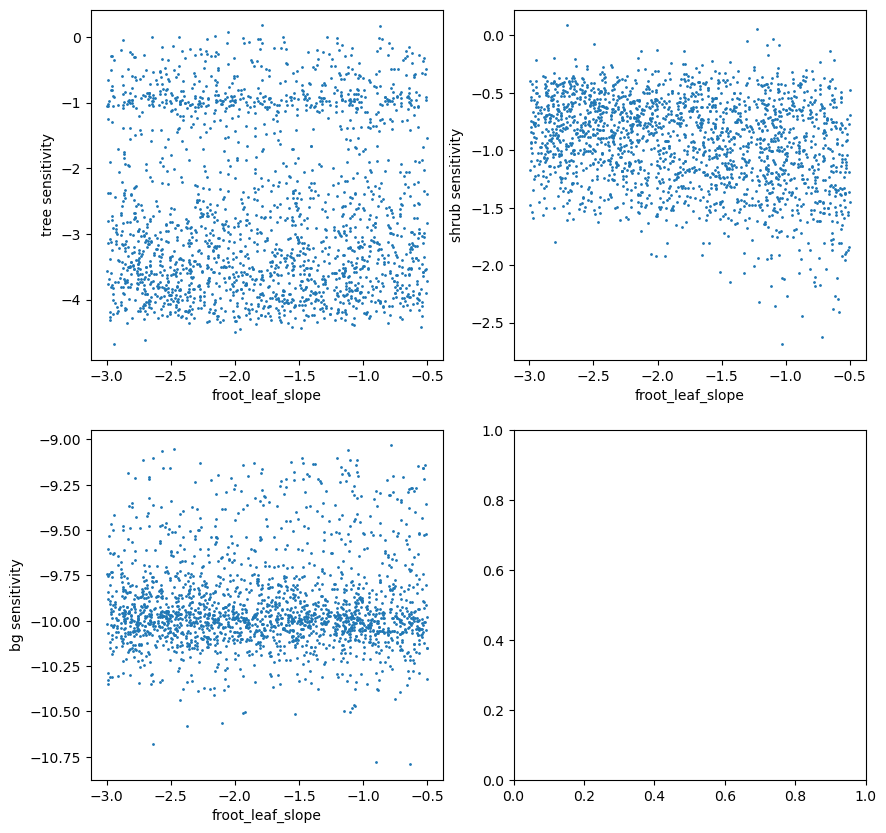

In [12]:
#alloccollect = get_params(prefix, 'froot_leaf_slope', 2000)

fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for i, (name,sens) in enumerate(zip(["tree","shrub","bg"],
                                    [tree_sensitivity, shrub_sensitivity,bgnpp_sensitivity])):
    ax = axes.flat[i]
    ax.plot(alloccollect[:, 11], sens, 'o', ms = 1)
    ax.set_xlabel('froot_leaf_slope')
    ax.set_ylabel(f'{name} sensitivity')

In [ ]:
""" Check the sensitivity of all quantities to alpha_fpg & alpha_fpg_p
    if insensitive, set to constants = 3
"""
alpha_fpg = get_params(prefix, 'alpha_fpg', 2000)
alpha_fpg_p = get_params(prefix, 'alpha_fpg_p', 2000)

fig, axes = plt.subplots(4, 4, figsize = (16, 16))
for i, col in enumerate(collection_obs.index.levels[0]):
    for j, stat in enumerate(['mean', 'slope']):
        ax = axes.flat[j*8 + i]

        obs = collection_obs.loc[col, stat].mean()
        sim = collection_sim[prefix][:, i, :, j * 2].mean(axis = 1)

        ax.axhline(obs, color = 'r', lw = 2)
        ax.plot(alpha_fpg, sim, 'o', ms = 1, color = 'b')
        ax.plot(alpha_fpg_p, sim, 'o', ms = 1, color = 'magenta')

## Find the parameter ranges for desired sensitivities and mean

In [14]:
selected_runs = np.where(
    (shrub_sensitivity >= 0) & (tree_sensitivity < 0.0) & (bgnpp_sensitivity > -10)
)[0] + 1
print(selected_runs)

[264]


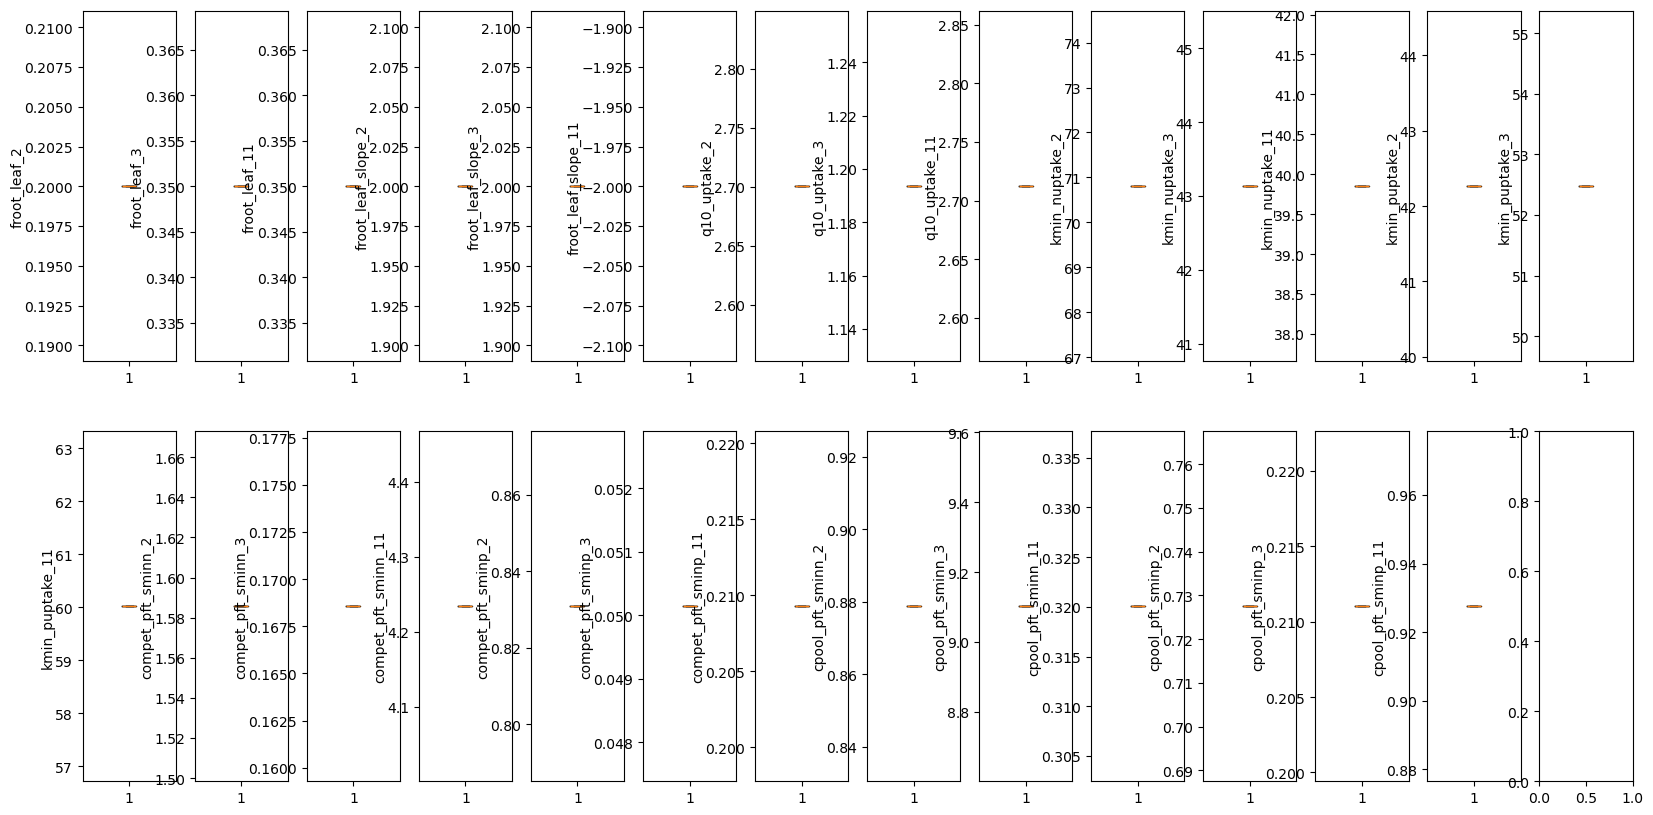

In [15]:
params_collect = {}
for parname in ['froot_leaf', 'froot_leaf_slope', 'q10_uptake', 'kmin_nuptake', 'kmin_puptake', 
                'compet_pft_sminn', 'compet_pft_sminp', 'compet_pft_sminp', 
                'cpool_pft_sminn', 'cpool_pft_sminp']: # , 'alpha_fpg', 'alpha_fpg_p'
    parvals = get_params(prefix, parname, 2000, selected_runs)
    if parvals.shape[1] == 1:
        params_collect[parname] = parvals
    else:
        for pft in [2, 3, 11]:
            params_collect[f'{parname}_{pft}'] = parvals[:, pft]

params_list = list(params_collect.keys())
fig, axes = plt.subplots(2, int(np.ceil(len(params_collect) / 2)), figsize = (20, 10))
fig.subplots_adjust(wspace = 0.2)
for i in range(len(params_list)):
    ax = axes.flat[i]
    ax.boxplot(params_collect[params_list[i]])
    ax.set_ylabel(params_list[i], labelpad=0)